# Transcription(CPU)

In [ ]:
import cv2
import easyocr
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Output, Button, VBox, HBox, Label
import ipywidgets as widgets
from IPython.display import display, clear_output
import json
from datetime import datetime
from tqdm import tqdm
import pandas as pd

print("✓ All imports successful!")
print("✓ Ready for OCR transcription")

# Initialize EasyOCR once (reusable)
print("\n🔄 Initializing EasyOCR reader...")
reader = easyocr.Reader(['en'], gpu=False)  # Change to gpu=True if available
print("✓ EasyOCR reader ready!")

Using CPU. Note: This module is much faster with a GPU.


✓ All imports successful!
✓ Ready for OCR transcription

🔄 Initializing EasyOCR reader...
✓ EasyOCR reader ready!


In [ ]:
class SingleImageTranscriber:
    """
    Transcribe a single image using EasyOCR
    Extract text, confidence scores, and bounding boxes
    """
    
    def __init__(self, image_path, reader=None):
        self.image_path = Path(image_path)
        self.reader = reader
        self.img = None
        self.results = []
        self.full_text = ""
        self.statistics = {}
        
        self._load_image()
    
    def _load_image(self):
        """Load image"""
        if not self.image_path.exists():
            raise FileNotFoundError(f"Image not found: {self.image_path}")
        
        self.img = cv2.imread(str(self.image_path))
        if self.img is None:
            raise ValueError(f"Cannot read image: {self.image_path}")
        
        print(f"✓ Loaded: {self.image_path.name}")
        print(f"  Size: {self.img.shape}")
    
    def transcribe(self, detail=True):
        """
        Transcribe image using EasyOCR
        
        Args:
            detail: If True, return detailed results with confidence
        """
        if self.reader is None:
            raise ValueError("Reader not initialized")
        
        # Convert to RGB for OCR
        img_rgb = cv2.cvtColor(self.img, cv2.COLOR_BGR2RGB)
        
        print("\n🔄 Transcribing image...")
        
        # Run OCR
        self.results = self.reader.readtext(img_rgb, detail=detail)
        
        # Extract text
        texts = []
        for result in self.results:
            if detail:
                text = result[1]
                confidence = result[2]
            else:
                text = result[1]
            texts.append(text)
        
        self.full_text = " ".join(texts)
        
        # Calculate statistics
        self._calculate_statistics()
        
        print(f"✓ Transcription complete!")
        print(f"  Text extracted: {len(self.full_text)} characters")
        print(f"  Detections: {len(self.results)}")
        
        return self.results
    
    def _calculate_statistics(self):
        """Calculate transcription statistics"""
        if not self.results:
            return
        
        confidences = [result[2] for result in self.results if len(result) > 2]
        
        self.statistics = {
            'total_detections': len(self.results),
            'total_characters': len(self.full_text),
            'total_words': len(self.full_text.split()),
            'avg_confidence': np.mean(confidences) if confidences else 0,
            'min_confidence': np.min(confidences) if confidences else 0,
            'max_confidence': np.max(confidences) if confidences else 0,
            'std_confidence': np.std(confidences) if confidences else 0
        }
    
    def visualize_results(self, figsize=(16, 10)):
        """Visualize OCR results with bounding boxes"""
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        
        # Left: Image with bounding boxes
        ax = axes[0]
        img_display = cv2.cvtColor(self.img, cv2.COLOR_BGR2RGB).copy()
        
        for result in self.results:
            bbox = result[0]
            text = result[1]
            confidence = result[2]
            
            # Draw bounding box
            pts = np.array(bbox, dtype=np.int32)
            cv2.polylines(img_display, [pts], True, (0, 255, 0), 2)  # Green
            
            # Put text
            x, y = int(bbox[0][0]), int(bbox[0][1])
            cv2.putText(img_display, f"{confidence:.2f}", (x, y - 5),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
        
        ax.imshow(img_display)
        ax.set_title(f'OCR Results: {len(self.results)} detections',
                    fontsize=12, fontweight='bold')
        ax.axis('off')
        
        # Right: Statistics
        ax = axes[1]
        ax.axis('off')
        
        stats_text = f"""
OCR TRANSCRIPTION RESULTS
{'='*40}

STATISTICS
{'='*40}
Total Detections:    {self.statistics['total_detections']}
Total Characters:    {self.statistics['total_characters']}
Total Words:         {self.statistics['total_words']}

CONFIDENCE SCORES
{'='*40}
Average:             {self.statistics['avg_confidence']:.1%}
Minimum:             {self.statistics['min_confidence']:.1%}
Maximum:             {self.statistics['max_confidence']:.1%}
Std Deviation:       {self.statistics['std_confidence']:.4f}

EXTRACTED TEXT (Preview)
{'='*40}
{self.full_text[:500]}{"..." if len(self.full_text) > 500 else ""}
        """
        
        ax.text(0.05, 0.5, stats_text, fontsize=10, family='monospace',
               verticalalignment='center', bbox=dict(boxstyle='round',
               facecolor='#ecf0f1', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
    
    def save_results(self, output_dir):
        """Save transcription results"""
        output_dir = Path(output_dir)
        output_dir.mkdir(exist_ok=True, parents=True)
        
        # Save full text
        txt_path = output_dir / f"{self.image_path.stem}_transcription.txt"
        with open(txt_path, 'w', encoding='utf-8') as f:
            f.write(self.full_text)
        
        # Save detailed results as JSON
        json_path = output_dir / f"{self.image_path.stem}_detailed.json"
        detailed_results = []
        
        for result in self.results:
            detailed_results.append({
                'text': result[1],
                'confidence': float(result[2]),
                'bbox': [[float(x), float(y)] for x, y in result[0]],
                'language': 'English'
            })
        
        with open(json_path, 'w', encoding='utf-8') as f:
            json.dump(detailed_results, f, indent=2, ensure_ascii=False)
        
        # Save statistics
        stats_path = output_dir / f"{self.image_path.stem}_statistics.json"
        stats_data = {
            'source_image': str(self.image_path),
            'statistics': self.statistics,
            'timestamp': datetime.now().isoformat()
        }
        
        with open(stats_path, 'w', encoding='utf-8') as f:
            json.dump(stats_data, f, indent=2)
        
        print(f"\n✓ Results saved:")
        print(f"  • Text: {txt_path}")
        print(f"  • Detailed: {json_path}")
        print(f"  • Statistics: {stats_path}")
        
        return {
            'text': txt_path,
            'detailed': json_path,
            'statistics': stats_path
        }

print("✓ SingleImageTranscriber class created")

✓ SingleImageTranscriber class created


In [ ]:
class FolderTranscriber:
    """
    Transcribe all images in a folder
    Supports both single images and line crops
    """
    
    def __init__(self, input_folder, output_base, reader=None):
        self.input_folder = Path(input_folder)
        self.output_base = Path(output_base)
        self.reader = reader
        self.image_files = []
        self.results = []
        
        self.output_base.mkdir(exist_ok=True, parents=True)
        self._find_images()
    
    def _find_images(self):
        """Find all images in folder"""
        image_extensions = ['.png', '.jpg', '.jpeg', '.tiff', '.bmp']
        
        for ext in image_extensions:
            self.image_files.extend(self.input_folder.glob(f"**/*{ext}"))
            self.image_files.extend(self.input_folder.glob(f"**/*{ext.upper()}"))
        
        self.image_files = sorted(list(set(self.image_files)))
        
        print(f"\n✓ Found {len(self.image_files)} images in {self.input_folder}")
    
    def transcribe_all(self):
        """Transcribe all images"""
        print(f"\n🔄 Transcribing {len(self.image_files)} images...\n")
        
        for idx, image_file in enumerate(self.image_files, 1):
            try:
                print(f"{idx}/{len(self.image_files)}: {image_file.name}")
                
                # Load and transcribe
                img = cv2.imread(str(image_file))
                if img is None:
                    print(f"  ❌ Cannot read")
                    continue
                
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                # Run OCR
                ocr_results = self.reader.readtext(img_rgb)
                
                # Extract text
                full_text = " ".join([result[1] for result in ocr_results])
                
                # Calculate confidence
                confidences = [result[2] for result in ocr_results]
                avg_confidence = np.mean(confidences) if confidences else 0
                
                # Store result
                result_data = {
                    'filename': image_file.name,
                    'path': str(image_file),
                    'text': full_text,
                    'detections': len(ocr_results),
                    'characters': len(full_text),
                    'avg_confidence': float(avg_confidence),
                    'status': 'success'
                }
                
                self.results.append(result_data)
                print(f"  ✓ {len(ocr_results)} detections")
            
            except Exception as e:
                print(f"  ❌ Error: {e}")
                self.results.append({
                    'filename': image_file.name,
                    'status': 'failed',
                    'error': str(e)
                })
        
        print(f"\n✓ Transcription complete!")
    
    def save_results(self):
        """Save all results"""
        # Create output structure
        text_dir = self.output_base / "texts"
        json_dir = self.output_base / "json"
        
        text_dir.mkdir(exist_ok=True, parents=True)
        json_dir.mkdir(exist_ok=True, parents=True)
        
        successful_count = 0
        
        # Save individual results
        for result in self.results:
            if result['status'] == 'success':
                # Save text
                txt_path = text_dir / f"{Path(result['filename']).stem}.txt"
                with open(txt_path, 'w', encoding='utf-8') as f:
                    f.write(result['text'])
                
                # Save JSON
                json_path = json_dir / f"{Path(result['filename']).stem}.json"
                with open(json_path, 'w', encoding='utf-8') as f:
                    json.dump(result, f, indent=2, ensure_ascii=False)
                
                successful_count += 1
        
        # Create batch summary
        summary = {
            'batch_info': {
                'input_folder': str(self.input_folder),
                'output_folder': str(self.output_base),
                'total_files': len(self.image_files),
                'successful': successful_count,
                'failed': len(self.image_files) - successful_count,
                'timestamp': datetime.now().isoformat()
            },
            'results': self.results
        }
        
        summary_path = self.output_base / "BATCH_SUMMARY.json"
        with open(summary_path, 'w', encoding='utf-8') as f:
            json.dump(summary, f, indent=2, ensure_ascii=False)
        
        # Create combined text file
        combined_text_path = self.output_base / "ALL_TEXT_COMBINED.txt"
        with open(combined_text_path, 'w', encoding='utf-8') as f:
            for result in self.results:
                if result['status'] == 'success':
                    f.write(f"\n{'='*70}\n")
                    f.write(f"File: {result['filename']}\n")
                    f.write(f"Confidence: {result['avg_confidence']:.1%}\n")
                    f.write(f"{'='*70}\n\n")
                    f.write(result['text'] + "\n")
        
        print(f"\n✓ Results saved:")
        print(f"  • Text files: {text_dir}")
        print(f"  • JSON files: {json_dir}")
        print(f"  • Summary: {summary_path}")
        print(f"  • Combined: {combined_text_path}")
        
        return {
            'text_dir': text_dir,
            'json_dir': json_dir,
            'summary': summary_path,
            'combined': combined_text_path
        }
    
    def get_statistics(self):
        """Get batch statistics"""
        successful = [r for r in self.results if r['status'] == 'success']
        
        if not successful:
            return None
        
        confidences = [r['avg_confidence'] for r in successful]
        characters = [r['characters'] for r in successful]
        detections = [r['detections'] for r in successful]
        
        return {
            'total_images': len(self.image_files),
            'successfully_transcribed': len(successful),
            'failed': len(self.image_files) - len(successful),
            'total_characters_extracted': sum(characters),
            'total_detections': sum(detections),
            'avg_confidence': np.mean(confidences),
            'avg_characters_per_image': np.mean(characters),
            'avg_detections_per_image': np.mean(detections)
        }

print("✓ FolderTranscriber class created")

✓ FolderTranscriber class created



SINGLE IMAGE TRANSCRIPTION
✓ Loaded: page_001_line_0018.png
  Size: (64, 1168, 3)

🔄 Transcribing image...


c:\Open Source\GSOC\org\HumanAI\gsoc-2026-renaissance-ocr-test\GSOC_2026_HumanAI_Test\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


✓ Transcription complete!
  Text extracted: 29 characters
  Detections: 5

📊 Transcription Results:
  Detections: 5
  Characters: 29
  Words: 5


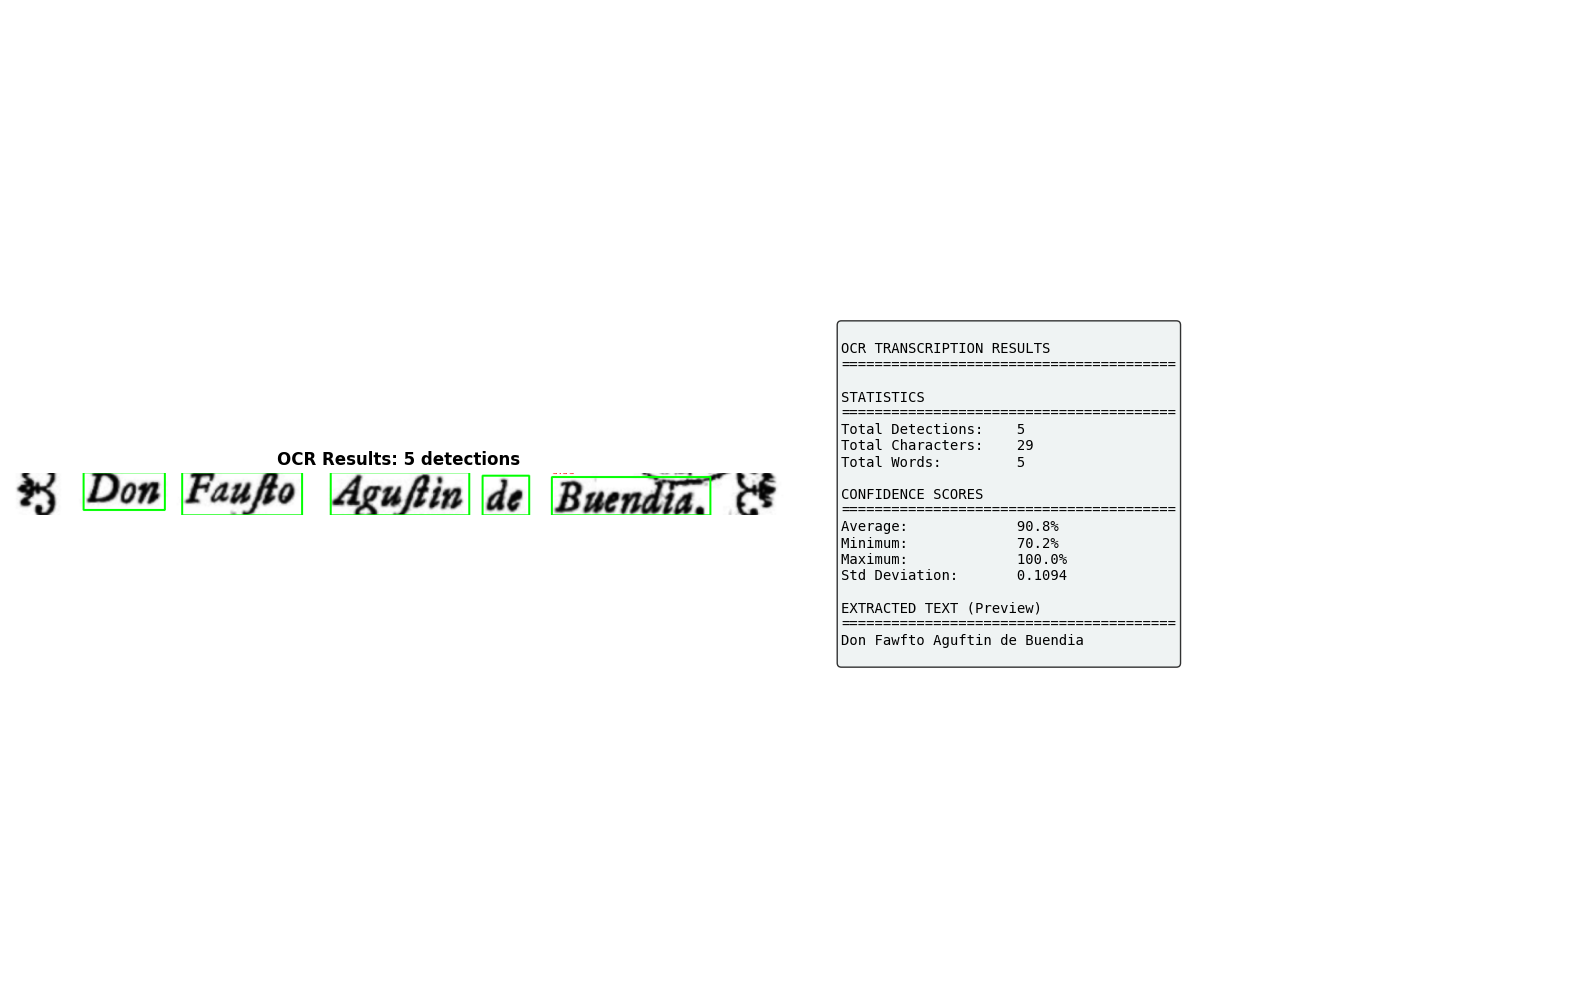


📈 Statistics:
  total_detections: 5
  total_characters: 29
  total_words: 5
  avg_confidence: 90.8%
  min_confidence: 70.2%
  max_confidence: 100.0%
  std_confidence: 10.9%


In [ ]:
print("\n" + "="*70)
print("SINGLE IMAGE TRANSCRIPTION")
print("="*70)

# Change this to your image path
image_path =r"data\Buendia_Instruccion\lines\page_001\lines\page_001_line_0018.png"

# Create transcriber
single_transcriber = SingleImageTranscriber(image_path, reader)

# Transcribe
results = single_transcriber.transcribe(detail=True)

# Display results
print(f"\n📊 Transcription Results:")
print(f"  Detections: {len(results)}")
print(f"  Characters: {len(single_transcriber.full_text)}")
print(f"  Words: {len(single_transcriber.full_text.split())}")

# Visualize
single_transcriber.visualize_results()

# Print statistics
print(f"\n📈 Statistics:")
for key, value in single_transcriber.statistics.items():
    if isinstance(value, float):
        if 'confidence' in key:
            print(f"  {key}: {value:.1%}")
        else:
            print(f"  {key}: {value:.2f}")
    else:
        print(f"  {key}: {value}")

In [ ]:
# Save results
output_dir = "single_image_ocr_output"
saved_files = single_transcriber.save_results(output_dir)

print(f"\n✓ Files saved to: {output_dir}")


✓ Results saved:
  • Text: single_image_ocr_output\page_001_line_0018_transcription.txt
  • Detailed: single_image_ocr_output\page_001_line_0018_detailed.json
  • Statistics: single_image_ocr_output\page_001_line_0018_statistics.json

✓ Files saved to: single_image_ocr_output


In [ ]:
print("\n" + "="*70)
print("EXTRACTED TEXT")
print("="*70)

print(f"\n{single_transcriber.full_text}")

# Also save to clipboard-friendly format
text_preview = single_transcriber.full_text[:500]
print(f"\n\n[Preview - First 500 characters]")
print(text_preview)


EXTRACTED TEXT

Don Fawfto Aguftin de Buendia


[Preview - First 500 characters]
Don Fawfto Aguftin de Buendia


In [ ]:
print("\n" + "="*70)
print("FOLDER TRANSCRIPTION")
print("="*70)

# Change this to your folder
folder_path = r"data\Buendia_Instruccion\lines\page_002\lines"
output_folder = "batch_ocr_output"

# Create folder transcriber
folder_transcriber = FolderTranscriber(folder_path, output_folder, reader)

# Transcribe all
folder_transcriber.transcribe_all()

# Save results
saved_paths = folder_transcriber.save_results()

# Get statistics
stats = folder_transcriber.get_statistics()

print(f"\n📊 Batch Statistics:")
if stats:
    print(f"  Total images: {stats['total_images']}")
    print(f"  Successfully transcribed: {stats['successfully_transcribed']}")
    print(f"  Failed: {stats['failed']}")
    print(f"  Total characters: {stats['total_characters_extracted']}")
    print(f"  Total detections: {stats['total_detections']}")
    print(f"  Avg confidence: {stats['avg_confidence']:.1%}")
    print(f"  Avg characters/image: {stats['avg_characters_per_image']:.0f}")
    print(f"  Avg detections/image: {stats['avg_detections_per_image']:.0f}")


FOLDER TRANSCRIPTION

✓ Found 29 images in C:\Open Source\GSOC\org\HumanAI\gsoc-2026-renaissance-ocr-test\GSOC_2026_HumanAI_Test\data\Buendia_Instruccion\lines\page_002\lines

🔄 Transcribing 29 images...

1/29: page_002_line_0002.png
  ✓ 3 detections
2/29: page_002_line_0004.png
  ✓ 6 detections
3/29: page_002_line_0006.png
  ✓ 8 detections
4/29: page_002_line_0007.png
  ✓ 5 detections
5/29: page_002_line_0008.png
  ✓ 7 detections
6/29: page_002_line_0010.png
  ✓ 7 detections
7/29: page_002_line_0011.png
  ✓ 6 detections
8/29: page_002_line_0012.png
  ✓ 6 detections
9/29: page_002_line_0013.png
  ✓ 7 detections
10/29: page_002_line_0015.png
  ✓ 6 detections
11/29: page_002_line_0017.png
  ✓ 2 detections
12/29: page_002_line_0018.png
  ✓ 5 detections
13/29: page_002_line_0019.png
  ✓ 3 detections
14/29: page_002_line_0020.png
  ✓ 8 detections
15/29: page_002_line_0021.png
  ✓ 7 detections
16/29: page_002_line_0023.png
  ✓ 4 detections
17/29: page_002_line_0025.png
  ✓ 3 detections
18/2


BATCH TRANSCRIPTION SUMMARY

Filename                       Detections      Confidence     
------------------------------------------------------------
page_002_line_0002.png         3               49.8%            
page_002_line_0004.png         6               58.3%            
page_002_line_0006.png         8               77.3%            
page_002_line_0007.png         5               61.9%            
page_002_line_0008.png         7               39.8%            
page_002_line_0010.png         7               48.3%            
page_002_line_0011.png         6               35.6%            
page_002_line_0012.png         6               66.7%            
page_002_line_0013.png         7               39.5%            
page_002_line_0015.png         6               67.3%            
page_002_line_0017.png         2               13.4%            
page_002_line_0018.png         5               42.2%            
page_002_line_0019.png         3               13.3%            
p

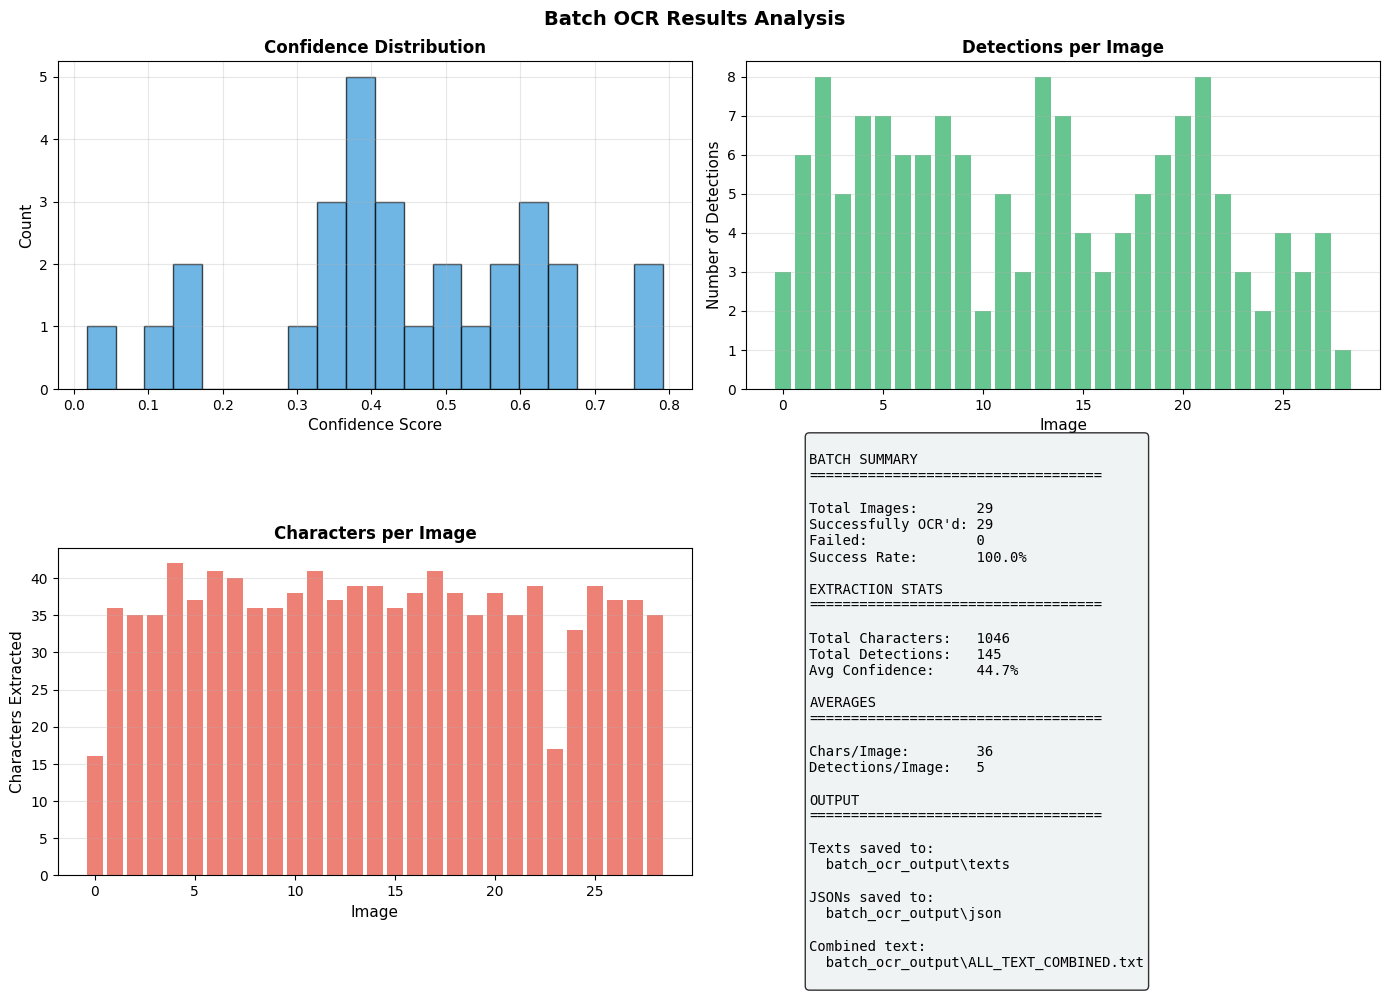

In [ ]:
print("\n" + "="*70)
print("BATCH TRANSCRIPTION SUMMARY")
print("="*70)

# Create DataFrame for visualization
df_results = pd.DataFrame(folder_transcriber.results)
df_successful = df_results[df_results['status'] == 'success']

if len(df_successful) > 0:
    print(f"\n{'Filename':<30} {'Detections':<15} {'Confidence':<15}")
    print("-" * 60)
    
    for idx, row in df_successful.iterrows():
        print(f"{row['filename']:<30} {row['detections']:<15} {row['avg_confidence']:.1%}{'':12}")
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Batch OCR Results Analysis', fontsize=14, fontweight='bold')
    
    # 1. Confidence distribution
    ax = axes[0, 0]
    ax.hist(df_successful['avg_confidence'], bins=20, color='#3498db', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Confidence Score', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title('Confidence Distribution', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # 2. Detections per image
    ax = axes[0, 1]
    ax.bar(range(len(df_successful)), df_successful['detections'], color='#27ae60', alpha=0.7)
    ax.set_xlabel('Image', fontsize=11)
    ax.set_ylabel('Number of Detections', fontsize=11)
    ax.set_title('Detections per Image', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 3. Characters extracted
    ax = axes[1, 0]
    ax.bar(range(len(df_successful)), df_successful['characters'], color='#e74c3c', alpha=0.7)
    ax.set_xlabel('Image', fontsize=11)
    ax.set_ylabel('Characters Extracted', fontsize=11)
    ax.set_title('Characters per Image', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 4. Summary stats
    ax = axes[1, 1]
    ax.axis('off')
    
    summary_text = f"""
BATCH SUMMARY
{'='*35}

Total Images:       {stats['total_images']}
Successfully OCR'd: {stats['successfully_transcribed']}
Failed:             {stats['failed']}
Success Rate:       {(stats['successfully_transcribed']/stats['total_images']*100):.1f}%

EXTRACTION STATS
{'='*35}

Total Characters:   {stats['total_characters_extracted']}
Total Detections:   {stats['total_detections']}
Avg Confidence:     {stats['avg_confidence']:.1%}

AVERAGES
{'='*35}

Chars/Image:        {stats['avg_characters_per_image']:.0f}
Detections/Image:   {stats['avg_detections_per_image']:.0f}

OUTPUT
{'='*35}

Texts saved to:
  {saved_paths['text_dir']}

JSONs saved to:
  {saved_paths['json_dir']}

Combined text:
  {saved_paths['combined']}
    """
    
    ax.text(0.1, 0.5, summary_text, fontsize=10, family='monospace',
           verticalalignment='center', bbox=dict(boxstyle='round',
           facecolor='#ecf0f1', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

In [ ]:
print("\n" + "="*70)
print("COMBINED TRANSCRIPTION")
print("="*70)

combined_file = Path(output_folder) / "ALL_TEXT_COMBINED.txt"

if combined_file.exists():
    with open(combined_file, 'r', encoding='utf-8') as f:
        combined_text = f.read()
    
    print(f"\n{combined_text[:1000]}")
    print("\n... (full text saved to file)")
    print(f"\n✓ Full transcription available at: {combined_file}")


COMBINED TRANSCRIPTION


File: page_002_line_0002.png
Confidence: 49.8%

5 D EL` T R AT 0

File: page_002_line_0004.png
Confidence: 58.3%

razon: '1 and6 alcrecamente CL Padre

File: page_002_line_0006.png
Confidence: 77.3%

Dlego fvarez 9 que 4 mas ae 10 @cho

File: page_002_line_0007.png
Confidence: 61.9%

moqera camlen CIa VircuQ IOS movmi-

File: page_002_line_0008.png
Confidenc

... (full text saved to file)

✓ Full transcription available at: batch_ocr_output\ALL_TEXT_COMBINED.txt


In [ ]:
print("\n" + "="*70)
print("EXPORT RESULTS TO CSV")
print("="*70)

csv_path = Path(output_folder) / "transcription_results.csv"

# Create DataFrame
df_export = pd.DataFrame([
    {
        'filename': r['filename'],
        'detections': r.get('detections', 0),
        'characters': r.get('characters', 0),
        'confidence': r.get('avg_confidence', 0),
        'status': r['status']
    }
    for r in folder_transcriber.results
])

df_export.to_csv(csv_path, index=False)

print(f"✓ CSV saved to: {csv_path}")
print(f"\n{df_export.to_string()}")


EXPORT RESULTS TO CSV
✓ CSV saved to: batch_ocr_output\transcription_results.csv

                  filename  detections  characters  confidence   status
0   page_002_line_0002.png           3          16    0.497763  success
1   page_002_line_0004.png           6          36    0.583261  success
2   page_002_line_0006.png           8          35    0.772997  success
3   page_002_line_0007.png           5          35    0.618775  success
4   page_002_line_0008.png           7          42    0.397513  success
5   page_002_line_0010.png           7          37    0.482994  success
6   page_002_line_0011.png           6          41    0.356043  success
7   page_002_line_0012.png           6          40    0.667444  success
8   page_002_line_0013.png           7          36    0.395085  success
9   page_002_line_0015.png           6          36    0.672988  success
10  page_002_line_0017.png           2          38    0.133635  success
11  page_002_line_0018.png           5          41   

# Checking total images in a folder

In [ ]:
"""
Scan your specific folder structure:
data/Buendia_Instruccion/lines/
├── page_001/
│   ├── lines/
│   │   ├── page_001_line_0001.png
│   │   ├── page_001_line_0002.png
│   │   └── ...
│   └── metadata/
├── page_002/
│   ├── lines/
│   │   ├── page_002_line_0001.png
│   │   └── ...
│   └── metadata/
└── ...
"""

print("="*70)
print("BUENDIA INSTRUCCION FOLDER SCANNER")
print("="*70)

from pathlib import Path
import os

# Your specific path
BASE_PATH = r"data\Buendia_Instruccion\lines"

base_path = Path(BASE_PATH)

print(f"\n📂 Base path: {base_path}")
print(f"✓ Exists: {base_path.exists()}\n")

if not base_path.exists():
    print("❌ Path not found!")
    print("Check your path is correct")
else:
    # List all page folders
    page_folders = sorted([f for f in base_path.iterdir() if f.is_dir()])
    
    print(f"📊 Found {len(page_folders)} page folders:\n")
    
    for idx, page_folder in enumerate(page_folders, 1):
        print(f"{idx}. {page_folder.name}")

BUENDIA INSTRUCCION FOLDER SCANNER

📂 Base path: C:\Open Source\GSOC\org\HumanAI\gsoc-2026-renaissance-ocr-test\GSOC_2026_HumanAI_Test\data\Buendia_Instruccion\lines
✓ Exists: True

📊 Found 64 page folders:

1. page_001
2. page_002
3. page_003
4. page_004
5. page_005
6. page_006
7. page_007
8. page_008
9. page_009
10. page_010
11. page_011
12. page_012
13. page_013
14. page_014
15. page_015
16. page_016
17. page_017
18. page_018
19. page_019
20. page_020
21. page_021
22. page_022
23. page_023
24. page_024
25. page_025
26. page_026
27. page_027
28. page_028
29. page_029
30. page_030
31. page_031
32. page_032
33. page_033
34. page_034
35. page_035
36. page_036
37. page_037
38. page_038
39. page_039
40. page_040
41. page_041
42. page_042
43. page_043
44. page_044
45. page_045
46. page_046
47. page_047
48. page_048
49. page_049
50. page_050
51. page_051
52. page_052
53. page_053
54. page_054
55. page_055
56. page_056
57. page_057
58. page_058
59. page_059
60. page_060
61. page_061
62. page

In [ ]:
"""
Analyze complete folder structure including lines and metadata
"""

print("\n" + "="*70)
print("DETAILED FOLDER STRUCTURE ANALYSIS")
print("="*70)

from pathlib import Path

BASE_PATH = r"data\Buendia_Instruccion\lines"

base_path = Path(BASE_PATH)

def analyze_structure(base_path):
    """Analyze folder structure"""
    
    page_folders = sorted([f for f in base_path.iterdir() if f.is_dir()])
    
    print(f"\n📊 STRUCTURE ANALYSIS:\n")
    
    total_images = 0
    total_metadata = 0
    structure_info = []
    
    for idx, page_folder in enumerate(page_folders, 1):
        page_name = page_folder.name
        
        # Check lines folder
        lines_folder = page_folder / "lines"
        metadata_folder = page_folder / "metadata"
        
        lines_count = 0
        metadata_count = 0
        
        if lines_folder.exists():
            # Count PNG images
            images = list(lines_folder.glob('*.png'))
            lines_count = len(images)
            total_images += lines_count
        
        if metadata_folder.exists():
            # Count metadata files
            metadata_files = list(metadata_folder.glob('*'))
            metadata_count = len(metadata_files)
            total_metadata += metadata_count
        
        status_lines = "✓" if lines_folder.exists() else "❌"
        status_meta = "✓" if metadata_folder.exists() else "❌"
        
        print(f"{idx}. {page_name}")
        print(f"   {status_lines} lines folder: {lines_count} images")
        print(f"   {status_meta} metadata folder: {metadata_count} files")
        
        structure_info.append({
            'page': page_name,
            'lines_images': lines_count,
            'metadata_files': metadata_count,
            'lines_path': str(lines_folder) if lines_folder.exists() else None,
            'metadata_path': str(metadata_folder) if metadata_folder.exists() else None
        })
    
    print(f"\n{'='*70}")
    print(f"📈 TOTAL SUMMARY:")
    print(f"   Total pages: {len(page_folders)}")
    print(f"   Total images (in lines folders): {total_images}")
    print(f"   Total metadata files: {total_metadata}")
    print(f"\n✅ Analysis complete!")
    
    return structure_info, total_images, total_metadata

# Run analysis
structure_info, total_images, total_metadata = analyze_structure(base_path)


DETAILED FOLDER STRUCTURE ANALYSIS

📊 STRUCTURE ANALYSIS:

1. page_001
   ✓ lines folder: 17 images
   ✓ metadata folder: 26 files
2. page_002
   ✓ lines folder: 29 images
   ✓ metadata folder: 44 files
3. page_003
   ✓ lines folder: 25 images
   ✓ metadata folder: 37 files
4. page_004
   ✓ lines folder: 25 images
   ✓ metadata folder: 30 files
5. page_005
   ✓ lines folder: 29 images
   ✓ metadata folder: 38 files
6. page_006
   ✓ lines folder: 28 images
   ✓ metadata folder: 35 files
7. page_007
   ✓ lines folder: 29 images
   ✓ metadata folder: 40 files
8. page_008
   ✓ lines folder: 27 images
   ✓ metadata folder: 34 files
9. page_009
   ✓ lines folder: 27 images
   ✓ metadata folder: 36 files
10. page_010
   ✓ lines folder: 28 images
   ✓ metadata folder: 36 files
11. page_011
   ✓ lines folder: 26 images
   ✓ metadata folder: 39 files
12. page_012
   ✓ lines folder: 28 images
   ✓ metadata folder: 32 files
13. page_013
   ✓ lines folder: 29 images
   ✓ metadata folder: 30 files


In [ ]:
"""
List all images from all page folders
"""

print("\n" + "="*70)
print("ALL IMAGES IN LINES FOLDERS")
print("="*70)

from pathlib import Path

BASE_PATH = r"data\Buendia_Instruccion\lines"

base_path = Path(BASE_PATH)

def list_all_images(base_path):
    """List all images with details"""
    
    all_images = []
    page_folders = sorted([f for f in base_path.iterdir() if f.is_dir()])
    
    print(f"\n{'#':<5} {'Page':<15} {'Image':<40} {'Size (MB)':<12} {'Status'}")
    print("-" * 75)
    
    idx = 1
    total_size = 0
    
    for page_folder in page_folders:
        page_name = page_folder.name
        lines_folder = page_folder / "lines"
        
        if not lines_folder.exists():
            print(f"⚠️ {page_name}: lines folder not found")
            continue
        
        # Get all images
        images = sorted(lines_folder.glob('*.png'))
        
        for img_path in images:
            size_mb = img_path.stat().st_size / (1024 * 1024)
            total_size += size_mb
            
            print(f"{idx:<5} {page_name:<15} {img_path.name:<40} {size_mb:<12.2f} ✓")
            
            all_images.append({
                'index': idx,
                'page': page_name,
                'filename': img_path.name,
                'path': str(img_path),
                'size_mb': size_mb
            })
            
            idx += 1
    
    print("-" * 75)
    print(f"\n✅ SUMMARY:")
    print(f"   Total images: {len(all_images)}")
    print(f"   Total size: {total_size:.2f} MB ({total_size/1024:.2f} GB)")
    print(f"   Average size: {total_size/len(all_images):.2f} MB" if all_images else "")
    
    return all_images

# List all images
all_images = list_all_images(base_path)


ALL IMAGES IN LINES FOLDERS

#     Page            Image                                    Size (MB)    Status
---------------------------------------------------------------------------
1     page_001        page_001_line_0003.png                   0.08         ✓
2     page_001        page_001_line_0006.png                   0.10         ✓
3     page_001        page_001_line_0007.png                   0.15         ✓
4     page_001        page_001_line_0009.png                   0.09         ✓
5     page_001        page_001_line_0010.png                   0.11         ✓
6     page_001        page_001_line_0011.png                   0.14         ✓
7     page_001        page_001_line_0013.png                   0.13         ✓
8     page_001        page_001_line_0014.png                   0.10         ✓
9     page_001        page_001_line_0015.png                   0.05         ✓
10    page_001        page_001_line_0016.png                   0.05         ✓
11    page_001        page_001_

In [ ]:
"""
Get detailed statistics about images
"""

print("\n" + "="*70)
print("IMAGE STATISTICS")
print("="*70)

import cv2
from pathlib import Path
import pandas as pd

BASE_PATH = r"data\Buendia_Instruccion\lines"

base_path = Path(BASE_PATH)

def get_image_statistics(base_path):
    """Get statistics about all images"""
    
    page_folders = sorted([f for f in base_path.iterdir() if f.is_dir()])
    
    stats = []
    
    print(f"\n🔍 Analyzing images...\n")
    
    for page_folder in page_folders:
        page_name = page_folder.name
        lines_folder = page_folder / "lines"
        
        if not lines_folder.exists():
            continue
        
        images = sorted(lines_folder.glob('*.png'))
        
        for idx, img_path in enumerate(images, 1):
            try:
                img = cv2.imread(str(img_path))
                
                if img is None:
                    print(f"❌ Cannot read: {img_path.name}")
                    continue
                
                height, width, channels = img.shape
                size_mb = img_path.stat().st_size / (1024 * 1024)
                
                stats.append({
                    'Page': page_name,
                    'Image': img_path.name,
                    'Size_MB': round(size_mb, 3),
                    'Width': width,
                    'Height': height,
                    'Channels': channels,
                    'Path': str(img_path)
                })
            except Exception as e:
                print(f"Error reading {img_path.name}: {e}")
    
    # Create DataFrame
    df = pd.DataFrame(stats)
    
    if len(df) > 0:
        print(df.to_string(index=False))
        
        print(f"\n{'='*70}")
        print("📊 STATISTICS SUMMARY:")
        print(f"{'='*70}\n")
        
        print(f"Total images: {len(df)}")
        print(f"\nSize Statistics:")
        print(f"  Total size: {df['Size_MB'].sum():.2f} MB ({df['Size_MB'].sum()/1024:.2f} GB)")
        print(f"  Average size: {df['Size_MB'].mean():.3f} MB")
        print(f"  Min size: {df['Size_MB'].min():.3f} MB")
        print(f"  Max size: {df['Size_MB'].max():.3f} MB")
        
        print(f"\nDimension Statistics:")
        print(f"  Most common width: {df['Width'].mode()[0] if len(df['Width'].mode()) > 0 else 'N/A'} px")
        print(f"  Most common height: {df['Height'].mode()[0] if len(df['Height'].mode()) > 0 else 'N/A'} px")
        print(f"  Width range: {df['Width'].min()} - {df['Width'].max()} px")
        print(f"  Height range: {df['Height'].min()} - {df['Height'].max()} px")
        
        print(f"\nPage Statistics:")
        page_counts = df.groupby('Page').size()
        for page, count in page_counts.items():
            print(f"  {page}: {count} images")
    else:
        print("❌ No valid images found")
    
    return df

# Get statistics
stats_df = get_image_statistics(base_path)


IMAGE STATISTICS

🔍 Analyzing images...

    Page                  Image  Size_MB  Width  Height  Channels                                                                                                                                                       Path
page_001 page_001_line_0003.png    0.075    793      64         3 C:\Open Source\GSOC\org\HumanAI\gsoc-2026-renaissance-ocr-test\GSOC_2026_HumanAI_Test\data\Buendia_Instruccion\lines\page_001\lines\page_001_line_0003.png
page_001 page_001_line_0006.png    0.102   1146      64         3 C:\Open Source\GSOC\org\HumanAI\gsoc-2026-renaissance-ocr-test\GSOC_2026_HumanAI_Test\data\Buendia_Instruccion\lines\page_001\lines\page_001_line_0006.png
page_001 page_001_line_0007.png    0.150   2110      64         3 C:\Open Source\GSOC\org\HumanAI\gsoc-2026-renaissance-ocr-test\GSOC_2026_HumanAI_Test\data\Buendia_Instruccion\lines\page_001\lines\page_001_line_0007.png
page_001 page_001_line_0009.png    0.094   1238      64         3 C:\Open 

In [ ]:
"""
Pipeline to process all images through OCR
"""

print("\n" + "="*70)
print("OCR PROCESSING PIPELINE")
print("="*70)

import cv2
from pathlib import Path
import json
from datetime import datetime

class OCRProcessingPipeline:
    """Pipeline to process all images through OCR"""
    
    def __init__(self, base_path, reader=None):
        self.base_path = Path(base_path)
        self.reader = reader
        self.results = []
        self.output_dir = Path("ocr_results")
        self.output_dir.mkdir(exist_ok=True)
    
    def process_all_pages(self):
        """Process all pages"""
        
        page_folders = sorted([f for f in self.base_path.iterdir() if f.is_dir()])
        
        print(f"\n🔄 Processing {len(page_folders)} pages...\n")
        
        for page_idx, page_folder in enumerate(page_folders, 1):
            page_name = page_folder.name
            lines_folder = page_folder / "lines"
            
            if not lines_folder.exists():
                print(f"⚠️ Skipping {page_name}: no lines folder")
                continue
            
            print(f"{page_idx}. Processing {page_name}...")
            
            # Process all images in this page
            images = sorted(lines_folder.glob('*.png'))
            
            page_results = self.process_page(page_name, images)
            
            print(f"   ✓ {len(page_results)} images processed")
    
    def process_page(self, page_name, image_paths):
        """Process single page"""
        
        page_results = []
        
        for idx, img_path in enumerate(image_paths, 1):
            try:
                # Read image
                img = cv2.imread(str(img_path))
                
                if img is None:
                    print(f"   ❌ Cannot read: {img_path.name}")
                    continue
                
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                # Process with OCR (if reader available)
                if self.reader:
                    try:
                        results = self.reader.readtext(img_rgb)
                        text = " ".join([r[1] for r in results])
                        confidence = sum([r[2] for r in results]) / len(results) if results else 0
                    except Exception as e:
                        print(f"   ⚠️ OCR error on {img_path.name}: {e}")
                        text = ""
                        confidence = 0
                else:
                    text = ""
                    confidence = 0
                
                # Store result
                result = {
                    'page': page_name,
                    'image': img_path.name,
                    'path': str(img_path),
                    'text': text,
                    'confidence': confidence,
                    'status': 'processed'
                }
                
                page_results.append(result)
                self.results.append(result)
            
            except Exception as e:
                print(f"   Error processing {img_path.name}: {e}")
        
        return page_results
    
    def save_results(self):
        """Save all results to files"""
        
        print(f"\n💾 Saving results...\n")
        
        # Save as JSON
        output_json = self.output_dir / "all_results.json"
        with open(output_json, 'w', encoding='utf-8') as f:
            json.dump(self.results, f, indent=2, ensure_ascii=False)
        
        print(f"✓ Saved: {output_json}")
        
        # Save summary
        summary = {
            'total_images': len(self.results),
            'timestamp': datetime.now().isoformat(),
            'results': self.results
        }
        
        output_summary = self.output_dir / "summary.json"
        with open(output_summary, 'w', encoding='utf-8') as f:
            json.dump(summary, f, indent=2)
        
        print(f"✓ Saved: {output_summary}")
        
        return output_json, output_summary

# Example usage (without OCR reader first)
BASE_PATH = r"data\Buendia_Instruccion\lines"

pipeline = OCRProcessingPipeline(BASE_PATH, reader=None)
pipeline.process_all_pages()
pipeline.save_results()


OCR PROCESSING PIPELINE

🔄 Processing 64 pages...

1. Processing page_001...
   ✓ 17 images processed
2. Processing page_002...
   ✓ 29 images processed
3. Processing page_003...
   ✓ 25 images processed
4. Processing page_004...
   ✓ 25 images processed
5. Processing page_005...
   ✓ 29 images processed
6. Processing page_006...
   ✓ 28 images processed
7. Processing page_007...
   ✓ 29 images processed
8. Processing page_008...
   ✓ 27 images processed
9. Processing page_009...
   ✓ 27 images processed
10. Processing page_010...
   ✓ 28 images processed
11. Processing page_011...
   ✓ 26 images processed
12. Processing page_012...
   ✓ 28 images processed
13. Processing page_013...
   ✓ 29 images processed
14. Processing page_014...
   ✓ 29 images processed
15. Processing page_015...
   ✓ 28 images processed
16. Processing page_016...
   ✓ 29 images processed
17. Processing page_017...
   ✓ 29 images processed
18. Processing page_018...
   ✓ 26 images processed
19. Processing page_0

(WindowsPath('ocr_results/all_results.json'),
 WindowsPath('ocr_results/summary.json'))

In [ ]:
"""
Create organized dataset from your images
"""

print("\n" + "="*70)
print("CREATE ORGANIZED DATASET")
print("="*70)

import shutil
from pathlib import Path

def create_organized_dataset(base_path, output_base="organized_dataset"):
    """Create organized dataset structure"""
    
    base_path = Path(base_path)
    output_base = Path(output_base)
    
    # Create main directories
    (output_base / 'all_images').mkdir(exist_ok=True, parents=True)
    (output_base / 'by_page').mkdir(exist_ok=True, parents=True)
    (output_base / 'split' / 'train').mkdir(exist_ok=True, parents=True)
    (output_base / 'split' / 'val').mkdir(exist_ok=True, parents=True)
    (output_base / 'split' / 'test').mkdir(exist_ok=True, parents=True)
    
    print(f"\n📁 Creating dataset structure...\n")
    
    page_folders = sorted([f for f in base_path.iterdir() if f.is_dir()])
    
    all_images = []
    
    # Organize by page
    for page_folder in page_folders:
        page_name = page_folder.name
        lines_folder = page_folder / "lines"
        
        if not lines_folder.exists():
            continue
        
        # Create page folder
        page_output_dir = output_base / 'by_page' / page_name
        page_output_dir.mkdir(exist_ok=True, parents=True)
        
        # Copy images
        images = sorted(lines_folder.glob('*.png'))
        
        for img_path in images:
            # Copy to all_images
            dst_all = output_base / 'all_images' / img_path.name
            shutil.copy2(img_path, dst_all)
            
            # Copy to by_page
            dst_page = page_output_dir / img_path.name
            shutil.copy2(img_path, dst_page)
            
            all_images.append(img_path)
        
        print(f"✓ {page_name}: {len(images)} images copied")
    
    # Split into train/val/test (70/15/15)
    print(f"\n📊 Creating train/val/test split...\n")
    
    import random
    random.shuffle(all_images)
    
    total = len(all_images)
    train_count = int(total * 0.7)
    val_count = int(total * 0.15)
    
    train_images = all_images[:train_count]
    val_images = all_images[train_count:train_count + val_count]
    test_images = all_images[train_count + val_count:]
    
    # Copy to splits
    for img in train_images:
        shutil.copy2(img, output_base / 'split' / 'train' / img.name)
    
    for img in val_images:
        shutil.copy2(img, output_base / 'split' / 'val' / img.name)
    
    for img in test_images:
        shutil.copy2(img, output_base / 'split' / 'test' / img.name)
    
    print(f"Train: {len(train_images)} images")
    print(f"Val: {len(val_images)} images")
    print(f"Test: {len(test_images)} images")
    
    print(f"\n✅ Dataset created at: {output_base}")
    
    return output_base

# Create dataset
dataset_dir = create_organized_dataset(base_path, "buendia_dataset")


CREATE ORGANIZED DATASET

📁 Creating dataset structure...

✓ page_001: 17 images copied
✓ page_002: 29 images copied
✓ page_003: 25 images copied
✓ page_004: 25 images copied
✓ page_005: 29 images copied
✓ page_006: 28 images copied
✓ page_007: 29 images copied
✓ page_008: 27 images copied
✓ page_009: 27 images copied
✓ page_010: 28 images copied
✓ page_011: 26 images copied
✓ page_012: 28 images copied
✓ page_013: 29 images copied
✓ page_014: 29 images copied
✓ page_015: 28 images copied
✓ page_016: 29 images copied
✓ page_017: 29 images copied
✓ page_018: 26 images copied
✓ page_019: 24 images copied
✓ page_020: 29 images copied
✓ page_021: 29 images copied
✓ page_022: 28 images copied
✓ page_023: 29 images copied
✓ page_024: 29 images copied
✓ page_025: 25 images copied
✓ page_026: 29 images copied
✓ page_027: 29 images copied
✓ page_028: 29 images copied
✓ page_029: 29 images copied
✓ page_030: 29 images copied
✓ page_031: 28 images copied
✓ page_032: 27 images copied
✓ page_033: 

In [ ]:
"""
Generate complete summary report
"""

print("\n" + "="*70)
print("COMPLETE SUMMARY REPORT")
print("="*70)

from pathlib import Path
import json

def generate_complete_report(base_path):
    """Generate complete report"""
    
    base_path = Path(base_path)
    
    page_folders = sorted([f for f in base_path.iterdir() if f.is_dir()])
    
    report = {
        'base_path': str(base_path),
        'total_pages': len(page_folders),
        'pages': [],
        'total_images': 0,
        'total_size_mb': 0
    }
    
    print(f"\n📊 GENERATING REPORT...\n")
    
    for page_folder in page_folders:
        page_name = page_folder.name
        lines_folder = page_folder / "lines"
        metadata_folder = page_folder / "metadata"
        
        page_info = {
            'name': page_name,
            'images_count': 0,
            'metadata_files': 0,
            'total_size_mb': 0,
            'has_lines': False,
            'has_metadata': False
        }
        
        # Count images
        if lines_folder.exists():
            images = list(lines_folder.glob('*.png'))
            page_info['images_count'] = len(images)
            page_info['has_lines'] = True
            
            total_size = sum(img.stat().st_size for img in images) / (1024 * 1024)
            page_info['total_size_mb'] = round(total_size, 2)
            
            report['total_images'] += len(images)
            report['total_size_mb'] += total_size
        
        # Count metadata
        if metadata_folder.exists():
            metadata_files = list(metadata_folder.glob('*'))
            page_info['metadata_files'] = len(metadata_files)
            page_info['has_metadata'] = True
        
        report['pages'].append(page_info)
    
    # Print report
    print(f"{'='*70}")
    print(f"BASE PATH: {base_path}")
    print(f"{'='*70}\n")
    
    print(f"📊 SUMMARY:")
    print(f"  Total pages: {report['total_pages']}")
    print(f"  Total images: {report['total_images']}")
    print(f"  Total size: {report['total_size_mb']:.2f} MB ({report['total_size_mb']/1024:.2f} GB)")
    
    print(f"\n📄 PAGES BREAKDOWN:\n")
    
    print(f"{'Page':<15} {'Images':<10} {'Size (MB)':<15} {'Metadata':<10}")
    print("-" * 50)
    
    for page_info in report['pages']:
        meta_status = "✓" if page_info['has_metadata'] else "❌"
        print(f"{page_info['name']:<15} {page_info['images_count']:<10} {page_info['total_size_mb']:<15.2f} {meta_status:<10}")
    
    print("-" * 50)
    print(f"\n✅ REPORT COMPLETE!")
    
    # Save report
    report_file = "buendia_report.json"
    with open(report_file, 'w') as f:
        json.dump(report, f, indent=2)
    
    print(f"✓ Report saved to: {report_file}")
    
    return report

# Generate report
report = generate_complete_report(base_path)


COMPLETE SUMMARY REPORT

📊 GENERATING REPORT...

BASE PATH: C:\Open Source\GSOC\org\HumanAI\gsoc-2026-renaissance-ocr-test\GSOC_2026_HumanAI_Test\data\Buendia_Instruccion\lines

📊 SUMMARY:
  Total pages: 64
  Total images: 1598
  Total size: 292.05 MB (0.29 GB)

📄 PAGES BREAKDOWN:

Page            Images     Size (MB)       Metadata  
--------------------------------------------------
page_001        17         1.81            ✓         
page_002        29         5.98            ✓         
page_003        25         5.32            ✓         
page_004        25         5.16            ✓         
page_005        29         5.46            ✓         
page_006        28         5.14            ✓         
page_007        29         6.22            ✓         
page_008        27         5.02            ✓         
page_009        27         4.53            ✓         
page_010        28         5.81            ✓         
page_011        26         4.77            ✓         
page_012        2

# Transcription (GPU)